In [78]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

# import matplotlib.pyplot as plt
# plt.rc('font', family='NanumBarunGothic')
# plt.rcParams['axes.unicode_minus'] =False

In [79]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import lightgbm
from google.colab import drive

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False


# 드라이브 마운트
drive.mount('/content/drive')

# 경로 설정
PATH = "/content/drive/MyDrive/열수요예측/"
df_raw = pd.read_csv(PATH + "train_heat.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
# 이상치 처리
df = df_raw.copy()
df.columns = [col.split('.')[1] for col in df.columns]
for col in df.columns:
    df[col] = np.where(df[col] == -99, np.nan, df[col])
df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])

# 필요없는 컬럼 제거
df.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True)

# 결측치 제거
df.dropna(inplace=True)

# 날짜 파싱 및 파생 변수 생성
df['tm'] = pd.to_datetime(df['tm'].astype(int), format='%Y%m%d%H')
df['month'] = df['tm'].dt.month
df['hour'] = df['tm'].dt.hour

# 요일 및 주말 여부
df['weekday'] = df['tm'].dt.dayofweek
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# 계절성 변수 (1년 주기)
df['dayofyear'] = df['tm'].dt.dayofyear
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

df['date_index'] = (df['tm'] - df['tm'].min()).dt.days
# 더 이상 필요 없는 컬럼 제거
df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

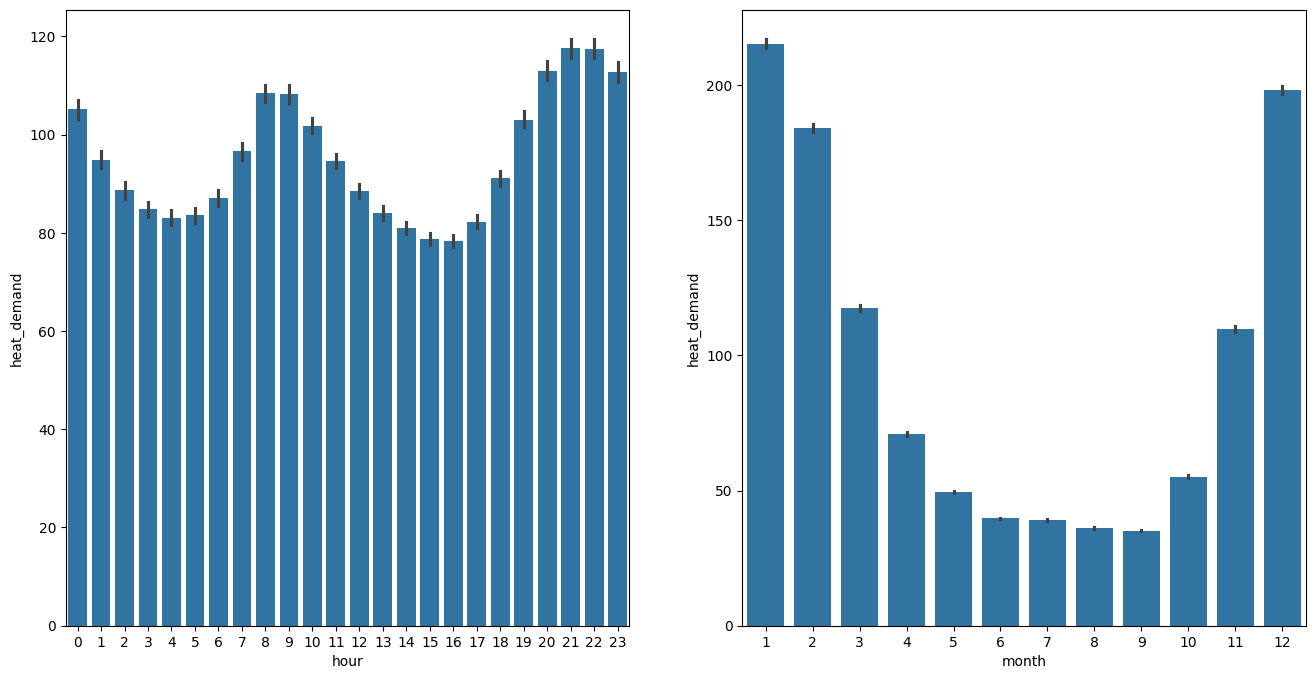

In [81]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.barplot(x='hour',y='heat_demand',data=df)
plt.subplot(1,2,2)
sns.barplot(x='month',y='heat_demand',data=df)
plt.show()

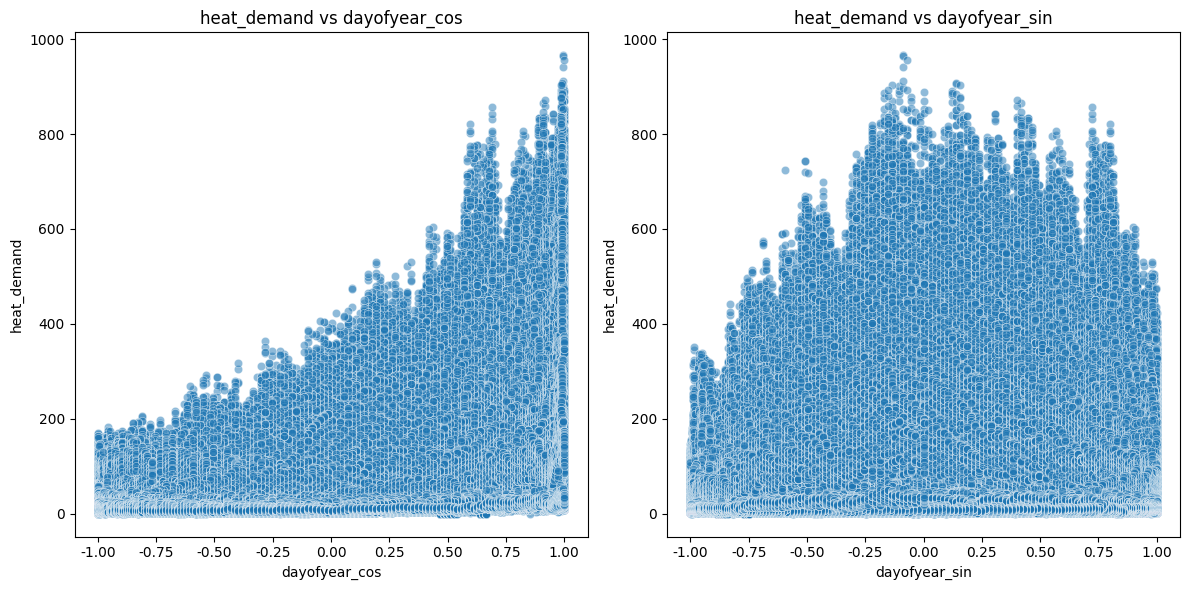

In [82]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='dayofyear_cos', y='heat_demand', data=df, alpha=0.5)
plt.title('heat_demand vs dayofyear_cos')

plt.subplot(1, 2, 2)
sns.scatterplot(x='dayofyear_sin', y='heat_demand', data=df, alpha=0.5)
plt.title('heat_demand vs dayofyear_sin')

plt.tight_layout()
plt.show()

In [83]:
# df['quadrant'] = np.select(
#         [
#             (df['wd'] >= 337.5) | (df['wd'] < 22.5),   # 북 (N)
#             (df['wd'] >= 22.5) & (df['wd'] < 67.5),    # 북동 (NE)
#             (df['wd'] >= 67.5) & (df['wd'] < 112.5),   # 동 (E)
#             (df['wd'] >= 112.5) & (df['wd'] < 157.5),  # 남동 (SE)
#             (df['wd'] >= 157.5) & (df['wd'] < 202.5),  # 남 (S)
#             (df['wd'] >= 202.5) & (df['wd'] < 247.5),  # 남서 (SW)
#             (df['wd'] >= 247.5) & (df['wd'] < 292.5),  # 서 (W)
#             (df['wd'] >= 292.5) & (df['wd'] < 337.5),  # 북서 (NW)
#         ],
#         ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
#         default='기타'  # 예외적처리
#     )

df['quadrant'] = np.select(
        [
            (df['wd'] >= 337.5) | (df['wd'] < 22.5),   # 북 (N)
            (df['wd'] >= 22.5) & (df['wd'] < 67.5),    # 북동 (NE)
            (df['wd'] >= 67.5) & (df['wd'] < 112.5),   # 동 (E)
            (df['wd'] >= 112.5) & (df['wd'] < 157.5),  # 남동 (SE)
            (df['wd'] >= 157.5) & (df['wd'] < 202.5),  # 남 (S)
            (df['wd'] >= 202.5) & (df['wd'] < 247.5),  # 남서 (SW)
            (df['wd'] >= 247.5) & (df['wd'] < 292.5),  # 서 (W)
            (df['wd'] >= 292.5) & (df['wd'] < 337.5),  # 북서 (NW)
        ],
        [1,2,3,4,5,6,7,8],
        default=-99  # 예외적처리
    )

In [84]:
# plt.figure(figsize=(16, 8))
# order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']  # 시계방향 순서
# sns.barplot(x='quadrant', y='heat_demand', data=df, order=order)
# plt.title("풍향 기준 정렬")
# plt.xlabel("풍향 (8방위)")
# plt.ylabel("평균 열수요량")
# plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

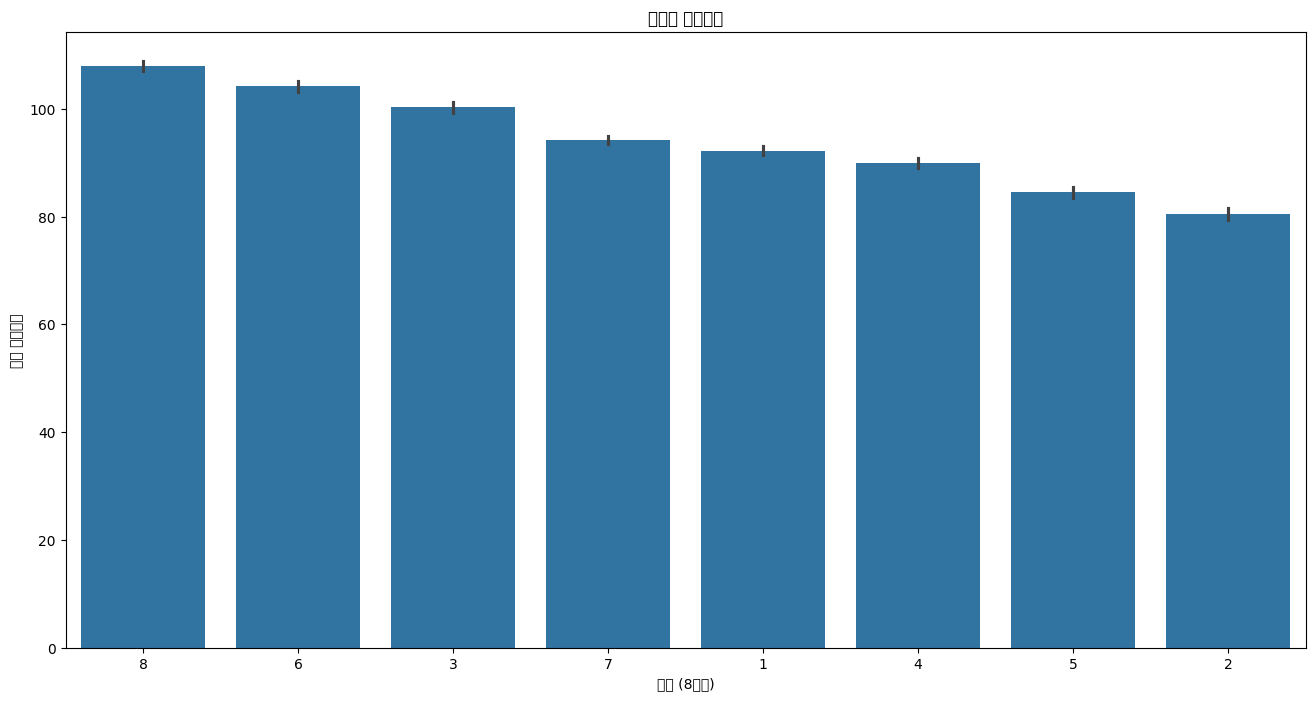

In [85]:
order_by_mean = (
    df.groupby('quadrant')['heat_demand']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

plt.figure(figsize=(16, 8))
sns.barplot(x='quadrant', y='heat_demand', data=df, order=order_by_mean)
plt.title("풍향별 열수요량")
plt.xlabel("풍향 (8방위)")
plt.ylabel("평균 열수요량")
plt.show()

In [86]:
df['rain_day'] = np.where(df['rn_day']>0,1,0)
df.drop('rn_day', axis=1, inplace=True)

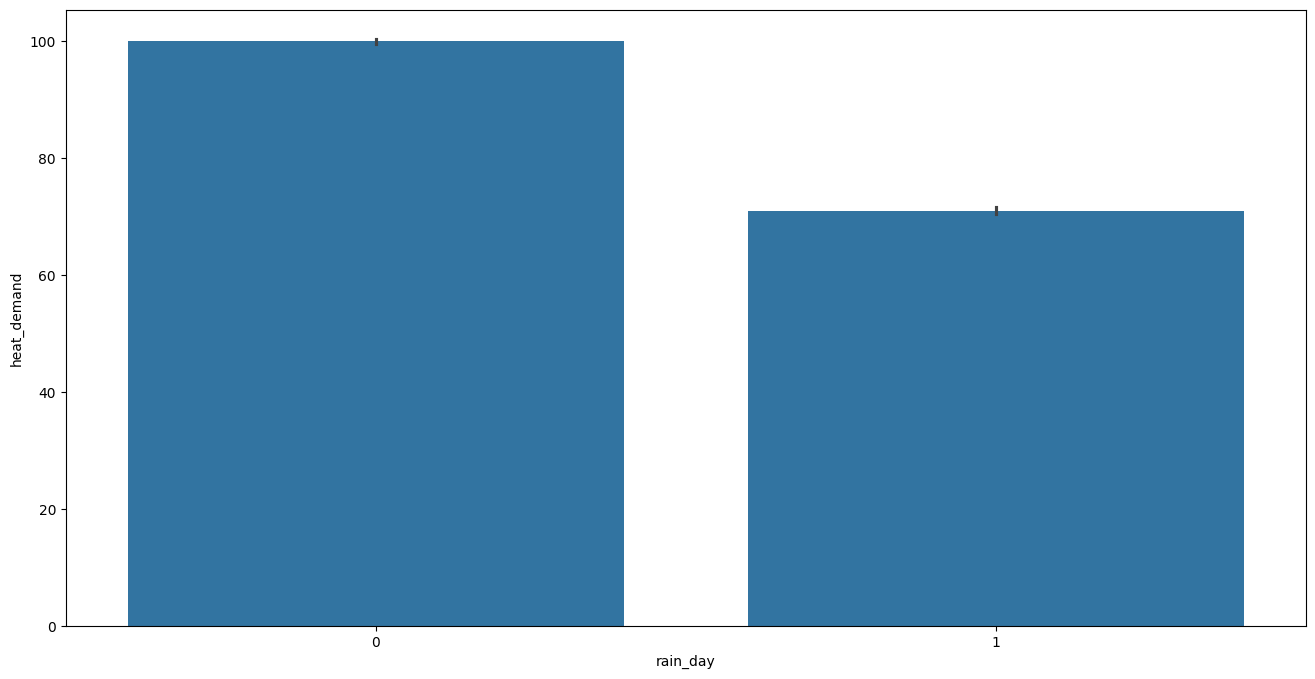

In [87]:
plt.figure(figsize=(16,8))
sns.barplot(x='rain_day',y='heat_demand',data=df)
plt.show()

In [88]:
df['heat_index_like'] = df['ta']*df['hm']
df['ta_moving_avg_24hr'] = df['ta'].rolling(window=24, min_periods=1).mean()
df['ta_moving_std_24hr'] = df['ta'].rolling(window=24, min_periods=1).std().round(2)

df['hm_moving_avg_24hr'] = df['hm'].rolling(window=24, min_periods=1).mean().round(2)
df['hm_moving_std_24hr'] = df['hm'].rolling(window=24, min_periods=1).std().round(2)

df['hm_moving_avg_12hr'] = df['hm'].rolling(window=12, min_periods=1).mean().round(2)



def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

df['season'] = df['month'].apply(get_season)

In [89]:
df

,branch_id,ta,wd,ws,hm,heat_demand,month,hour,is_weekend,dayofyear_sin,...,date_index,quadrant,rain_day,heat_index_like,ta_moving_avg_24hr,ta_moving_std_24hr,hm_moving_avg_24hr,hm_moving_std_24hr,hm_moving_avg_12hr,season
0,A,-10.1,78.3,0.5,68.2,281.0,1,1,0,1.721336e-02,...,0,3,0,-688.82,-10.100000,NaN,68.20,NaN,68.20,winter
1,A,-10.2,71.9,0.6,69.9,262.0,1,2,0,1.721336e-02,...,0,3,0,-712.98,-10.150000,0.07,69.05,1.20,69.05,winter
2,A,-10.0,360.0,0.0,69.2,266.0,1,3,0,1.721336e-02,...,0,1,0,-692.00,-10.100000,0.10,69.10,0.85,69.10,winter
3,A,-9.3,155.9,0.5,65.0,285.0,1,4,0,1.721336e-02,...,0,4,0,-604.50,-9.900000,0.41,68.08,2.17,68.08,winter
4,A,-9.0,74.3,1.9,63.5,283.0,1,5,0,1.721336e-02,...,0,3,0,-571.50,-9.720000,0.54,67.16,2.78,67.16,winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499296,S,3.2,233.5,0.4,91.5,34.0,12,19,1,6.432491e-16,...,1094,6,1,292.80,3.637500,0.64,92.96,4.97,89.87,winter
499297,S,2.9,227.4,0.1,92.1,35.0,12,20,1,6.432491e-16,...,1094,6,1,267.09,3.620833,0.66,93.09,4.90,89.37,winter
499298,S,2.1,360.0,0.0,93.3,35.0,12,21,1,6.432491e-16,...,1094,1,1,195.93,3.562500,0.73,93.35,4.72,89.18,winter
499299,S,2.2,30.0,1.4,95.5,40.0,12,22,1,6.432491e-16,...,1094,2,1,210.10,3.529167,0.77,93.38,4.73,89.41,winter


In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd



X = df[['ta','wd','ws','hm','month','hour','is_weekend','dayofyear_sin','dayofyear_cos','ta_moving_avg_24hr', 'ta_moving_std_24hr', 'hm_moving_avg_24hr','hm_moving_std_24hr','hm_moving_avg_12hr']]  # 독립변수들
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = add_constant(X)

vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

df.drop(columns =['ta_moving_avg_24hr'], inplace=True)

               feature        VIF
0                const  72.792179
1                   ta  21.676269
2                   wd   1.033885
3                   ws   1.277210
4                   hm   4.579810
5                month   2.568866
6                 hour   1.440184
7           is_weekend   1.001034
8        dayofyear_sin   3.753613
9        dayofyear_cos   7.307735
10  ta_moving_avg_24hr  25.220492
11  ta_moving_std_24hr   1.979526
12  hm_moving_avg_24hr   5.229763
13  hm_moving_std_24hr   1.732378
14  hm_moving_avg_12hr   5.631085


In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd



X = df[['ta','wd','ws','hm','month','hour','is_weekend','dayofyear_sin','dayofyear_cos', 'ta_moving_std_24hr', 'hm_moving_avg_24hr','hm_moving_std_24hr','hm_moving_avg_12hr']]  # 독립변수들
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = add_constant(X)

vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)


               feature        VIF
0                const  70.168400
1                   ta   6.845212
2                   wd   1.033580
3                   ws   1.272569
4                   hm   3.139597
5                month   2.567374
6                 hour   1.328224
7           is_weekend   1.000840
8        dayofyear_sin   3.574991
9        dayofyear_cos   6.001262
10  ta_moving_std_24hr   1.967467
11  hm_moving_avg_24hr   5.194068
12  hm_moving_std_24hr   1.715131
13  hm_moving_avg_12hr   5.236683


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027788 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2984
[LightGBM] [Info] Number of data points in the train set: 358276, number of used features: 38
[LightGBM] [Info] Start training from score 95.126852
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's rmse: 10.1979	valid_0's l2: 103.997
LightGBM 결과
RMSE : 10.19791592807772
MAE  : 6.416620917053869


R2   : 0.9921933351475916


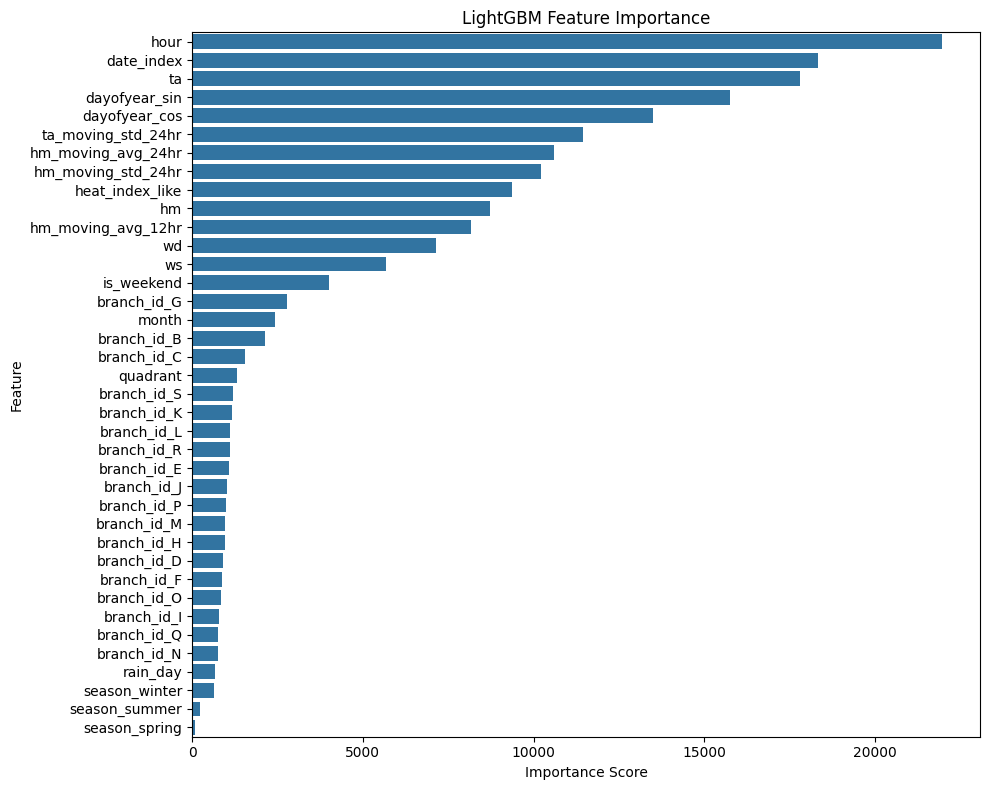

In [92]:
# 원-핫 인코딩
df = pd.get_dummies(df, columns=['branch_id','season'], drop_first=True)

# x, y 분리
x = df.drop('heat_demand', axis=1)
y = df['heat_demand']

# 분할
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)


# LightGBM 모델 정의
LEARNING_RATE=0.05
model = lightgbm.LGBMRegressor(
        objective='regression',
        learning_rate=LEARNING_RATE,
        n_estimators=3000,
        num_leaves=64,
        max_depth=8
    )

# 학습
model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    eval_metric='rmse',
    callbacks=[lightgbm.early_stopping(stopping_rounds=10)]
)
rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, model.predict(x_test)))
# 평가 출력
print("LightGBM 결과")
print("RMSE :", rmse)
print("MAE  :", sk.metrics.mean_absolute_error(y_test, model.predict(x_test)))
print("R2   :", sk.metrics.r2_score(y_test, model.predict(x_test)))

# 중요도 추출 (split은 등장 횟수 기준, gain은 손실 감소량 기준)
importances = model.feature_importances_  # 기본은 split 기준
feature_names = x.columns

# 정리해서 시각화
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=importance_df, y=importance_df.index)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [93]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np


xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.05,
    n_estimators=3000,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    )
xgb_model.fit(x_train, y_train)

y_pred = xgb_model.predict(x_test)
print('model_score:', xgb_model.score(x_test, y_test))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('MAPE:', mean_absolute_percentage_error(y_test, y_pred))
print('R2-Score:', r2_score(y_test, y_pred))

model_score: 0.9938694175894163
MAE: 5.55851958830968
MSE: 81.66934158887125
RMSE: 9.037109138926631
MAPE: 4179526975042.5166
R2-Score: 0.9938694175894163


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(x_train, y_train)

# 평가 지표
pred_rf = model_rf.predict(x_test)
rmse_rf = np.sqrt(sk.metrics.mean_squared_error(y_test, pred_rf))
print("\nRandom Forest 결과")
print("RMSE :", rmse_rf)
print("MAE  :", sk.metrics.mean_absolute_error(y_test, pred_rf))
print("R2   :", sk.metrics.r2_score(y_test, pred_rf))

# 중요도 시각화
importance_rf = pd.Series(model_rf.feature_importances_, index=x.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importance_rf, y=importance_rf.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
y_pred = model.predict(x_test)

# 산점도 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 대각선
plt.xlabel("실제 열수요 (y_test)")
plt.ylabel("예측 열수요 (y_pred)")
plt.title("예측값 vs 실제값 비교")
plt.grid(True)
plt.tight_layout()
plt.show()